<a href="https://colab.research.google.com/github/Anhali/MLproject/blob/main/Premier_League_Resuls_Predector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
df = pd.read_csv('https://www.kaggle.com/api/v1/datasets/download/evangower/premier-league-matches-19922022/premier-league-matches.csv')
df

,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A
...,...,...,...,...,...,...,...,...
12021,2023,38,2023-05-28,Everton,1,0,Bournemouth,H
12022,2023,38,2023-05-28,Leicester City,2,1,West Ham,H
12023,2023,38,2023-05-28,Aston Villa,2,1,Brighton,H
12024,2023,38,2023-05-28,Leeds United,1,4,Tottenham,A


In [3]:
# first look
print(df.shape)           # how many rows and columns?
print(df.head())          # what does it actually look like?
print(df.dtypes)          # what type is each column?

(12026, 8)
   Season_End_Year  Wk        Date            Home  HomeGoals  AwayGoals  \
0             1993   1  1992-08-15   Coventry City          2          1   
1             1993   1  1992-08-15    Leeds United          2          1   
2             1993   1  1992-08-15   Sheffield Utd          2          1   
3             1993   1  1992-08-15  Crystal Palace          3          3   
4             1993   1  1992-08-15         Arsenal          2          4   

             Away FTR  
0   Middlesbrough   H  
1       Wimbledon   H  
2  Manchester Utd   H  
3       Blackburn   D  
4    Norwich City   A  
Season_End_Year     int64
Wk                  int64
Date               object
Home               object
HomeGoals           int64
AwayGoals           int64
Away               object
FTR                object
dtype: object


In [4]:
# decode FTR into readable labels first
df['result'] = df['FTR'].map({'H': 'Home Win', 'A': 'Away Win', 'D': 'Draw'})

print(df['result'].value_counts())
print(df['result'].value_counts(normalize=True).round(3))

result
Home Win    5519
Away Win    3410
Draw        3097
Name: count, dtype: int64
result
Home Win    0.459
Away Win    0.284
Draw        0.258
Name: proportion, dtype: float64


In [5]:
# for numeric features
print(df.describe())

# encode result so we can run the correlation
le_temp = LabelEncoder()
df['result_encoded'] = le_temp.fit_transform(df['result'])

# quick correlation check
print(df.corr(numeric_only=True)['result_encoded'].sort_values())

       Season_End_Year            Wk     HomeGoals     AwayGoals
count     12026.000000  12026.000000  12026.000000  12026.000000
mean       2007.713620     19.730501      1.524364      1.142525
std           9.072559     11.123916      1.306417      1.133930
min        1993.000000      1.000000      0.000000      0.000000
25%        2000.000000     10.000000      1.000000      0.000000
50%        2008.000000     20.000000      1.000000      1.000000
75%        2016.000000     29.000000      2.000000      2.000000
max        2023.000000     42.000000      9.000000      9.000000
AwayGoals         -0.624102
Season_End_Year   -0.028324
Wk                 0.016795
HomeGoals          0.619380
result_encoded     1.000000
Name: result_encoded, dtype: float64


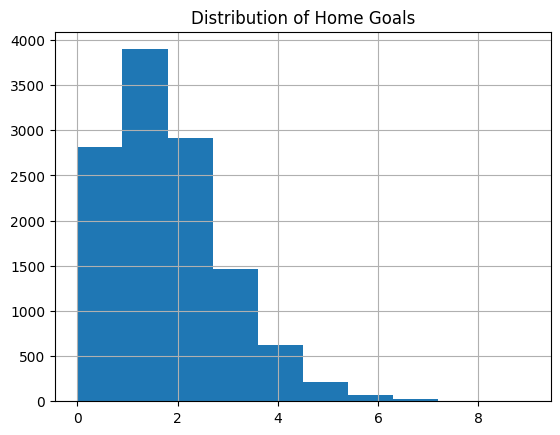

In [6]:
df['HomeGoals'].hist(bins=10)
plt.title('Distribution of Home Goals')
plt.show()

In [7]:
# decode the result column first
df['result'] = df['FTR'].map({'H': 'Home Win', 'A': 'Away Win', 'D': 'Draw'})
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [8]:
# build pre-match rolling averages (what we'd actually know before kickoff)
df['home_goals_avg'] = df.groupby('Home')['HomeGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['away_goals_avg'] = df.groupby('Away')['AwayGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['home_conceded_avg'] = df.groupby('Home')['AwayGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['away_conceded_avg'] = df.groupby('Away')['HomeGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df = df.dropna()
df

,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR,result,result_encoded,home_goals_avg,away_goals_avg,home_conceded_avg,away_conceded_avg
22,1993,3,1992-08-22,Aston Villa,1,1,Southampton,D,Draw,1,1.0,1.0,1.0,3.0
23,1993,3,1992-08-22,Oldham Athletic,5,3,Nott'ham Forest,H,Home Win,2,1.0,0.0,1.0,2.0
24,1993,3,1992-08-22,QPR,3,2,Sheffield Utd,H,Home Win,2,3.0,1.0,1.0,2.0
25,1993,3,1992-08-22,Middlesbrough,4,1,Leeds United,H,Home Win,2,2.0,1.0,0.0,1.0
26,1993,3,1992-08-22,Manchester Utd,1,1,Ipswich Town,D,Draw,1,0.0,1.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12021,2023,38,2023-05-28,Manchester Utd,2,1,Fulham,H,Home Win,2,2.0,1.2,0.2,1.0
12022,2023,38,2023-05-28,Chelsea,1,1,Newcastle Utd,D,Draw,1,0.6,2.6,1.6,1.6
12023,2023,38,2023-05-28,Crystal Palace,1,1,Nott'ham Forest,D,Draw,1,1.6,1.2,1.0,2.2
12024,2023,38,2023-05-28,Arsenal,5,0,Wolves,H,Home Win,2,2.8,0.6,1.8,2.6


In [9]:
# Machine Learning algorithms require numerical input. This step converts
#categorical text data (like team names) into numerical representations
# that the model can understand and process.
le_home   = LabelEncoder()
le_away   = LabelEncoder()
le_result = LabelEncoder()

df['home_encoded']   = le_home.fit_transform(df['Home'])
df['away_encoded']   = le_away.fit_transform(df['Away'])
df['result_encoded'] = le_result.fit_transform(df['result'])

In [10]:
#example of what meaning number 38
decoded_away_team = le_away.inverse_transform([38])
print(f"Le chiffre 38 encode l'équipe : {decoded_away_team[0]}")

Le chiffre 38 encode l'équipe : Southampton


In [11]:
df

,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR,result,result_encoded,home_goals_avg,away_goals_avg,home_conceded_avg,away_conceded_avg,home_encoded,away_encoded
22,1993,3,1992-08-22,Aston Villa,1,1,Southampton,D,Draw,1,1.0,1.0,1.0,3.0,1,38
23,1993,3,1992-08-22,Oldham Athletic,5,3,Nott'ham Forest,H,Home Win,2,1.0,0.0,1.0,2.0,32,31
24,1993,3,1992-08-22,QPR,3,2,Sheffield Utd,H,Home Win,2,3.0,1.0,1.0,2.0,34,36
25,1993,3,1992-08-22,Middlesbrough,4,1,Leeds United,H,Home Win,2,2.0,1.0,0.0,1.0,28,23
26,1993,3,1992-08-22,Manchester Utd,1,1,Ipswich Town,D,Draw,1,0.0,1.0,3.0,0.0,27,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12021,2023,38,2023-05-28,Manchester Utd,2,1,Fulham,H,Home Win,2,2.0,1.2,0.2,1.0,27,19
12022,2023,38,2023-05-28,Chelsea,1,1,Newcastle Utd,D,Draw,1,0.6,2.6,1.6,1.6,14,29
12023,2023,38,2023-05-28,Crystal Palace,1,1,Nott'ham Forest,D,Draw,1,1.6,1.2,1.0,2.2,16,31
12024,2023,38,2023-05-28,Arsenal,5,0,Wolves,H,Home Win,2,2.8,0.6,1.8,2.6,0,49


In [12]:
from sklearn.model_selection import train_test_split , StratifiedKFold, cross_val_score, GridSearchCV
features = ['home_encoded', 'away_encoded',
            'home_goals_avg', 'away_goals_avg',
            'home_conceded_avg', 'away_conceded_avg']

X = df[features]
y = df['result_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# Calcul robuste des occurrences de chaque classe
class_counts_lr = y_train.value_counts()
count_class_0 = class_counts_lr.get(0, 1)
count_class_1 = class_counts_lr.get(1, 1)
count_class_2 = class_counts_lr.get(2, 1)

print('Home_win (Classe 2) dans les données d\'entraînement :', count_class_2)
print('Away_win (Classe 0) dans les données d\'entraînement :', count_class_0)
print('Draw (Classe 1) dans les données d\'entraînement :', count_class_1)

Home_win (Classe 2) dans les données d'entraînement : 4373
Away_win (Classe 0) dans les données d'entraînement : 2734
Draw (Classe 1) dans les données d'entraînement : 2451


In [14]:
# Calcul exact des poids associés aux bons index de classe
total_samples_lr = count_class_0 + count_class_1 + count_class_2
weight_0 = count_class_0 / total_samples_lr
weight_1 = count_class_1 / total_samples_lr
weight_2 = count_class_2 / total_samples_lr

print('Poids corrigé pour Away_win (Classe 0) :', weight_0)
print('Poids corrigé pour Draw (Classe 1) :', weight_1)
print('Poids corrigé pour Home_win (Classe 2) :', weight_2)

Poids corrigé pour Away_win (Classe 0) : 0.2860431052521448
Poids corrigé pour Draw (Classe 1) : 0.2564344005021971
Poids corrigé pour Home_win (Classe 2) : 0.4575224942456581


In [15]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score

# Grille de paramètres corrigée utilisant l'association clé/valeur exacte
param_grid_lr = {
    'C': [0.1, 1, 10, 100],
    'class_weight': ['balanced', {0: weight_0, 1: weight_1, 2: weight_2}]
}

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

LR_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
grid = GridSearchCV(LR_model, param_grid=param_grid_lr, cv=cv_inner, scoring='f1_weighted', n_jobs=-1)

In [16]:
import time
# Démarrage du chronomètre
start_time = time.time()

# Validation croisée imbriquée avec les poids corrigés
grid = GridSearchCV(LR_model, param_grid=param_grid_lr, cv=cv_inner, scoring='f1_weighted', n_jobs=-1)
scores = cross_val_score(grid, X_train, y_train, cv=cv_outer, scoring='f1_weighted', n_jobs=-1)

print("Scores F1-weighted par pli :", scores)
print("Score F1-weighted moyen :", scores.mean())

Scores F1-weighted par pli : [0.41066319 0.41789351 0.42160857 0.44112792 0.42888209]
Score F1-weighted moyen : 0.4240350536194943


In [17]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time

# Entraînement final avec recherche sur grille sur l'ensemble d'entraînement
start_time = time.time()
grid.fit(X_train, y_train)
best_lr_model = grid.best_estimator_
lr_training_time = time.time() - start_time

print("Meilleurs paramètres : ", grid.best_params_)
print("Temps d'entraînement du modèle : {:.3f} secondes".format(lr_training_time))
print("\nRapport de classification sur le Train Set (Régression Logistique) :")
print(classification_report(y_train, best_lr_model.predict(X_train), target_names=le_result.classes_))

Meilleurs paramètres :  {'C': 100, 'class_weight': 'balanced'}
Temps d'entraînement du modèle : 10.939 secondes

Rapport de classification sur le Train Set (Régression Logistique) :
              precision    recall  f1-score   support

    Away Win       0.39      0.55      0.46      2734
        Draw       0.26      0.15      0.19      2451
    Home Win       0.55      0.55      0.55      4373

    accuracy                           0.45      9558
   macro avg       0.40      0.42      0.40      9558
weighted avg       0.43      0.45      0.43      9558



In [18]:
# Classfication report for training data
y_pred = best_lr_model.predict(X_test)
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.36      0.53      0.43       654
           1       0.24      0.12      0.16       628
           2       0.56      0.58      0.57      1108

    accuracy                           0.44      2390
   macro avg       0.39      0.41      0.39      2390
weighted avg       0.42      0.44      0.42      2390



In [19]:
 #decode numbers back into readable labels
pred_labels = le_result.inverse_transform(y_pred[:10])
print(pred_labels)
# ['Away Win' 'Home Win' 'Home Win' ...]

['Away Win' 'Away Win' 'Home Win' 'Home Win' 'Home Win' 'Home Win'
 'Home Win' 'Draw' 'Home Win' 'Away Win']


In [20]:
print(classification_report(y_test, y_pred,
                             target_names=le_result.classes_))

              precision    recall  f1-score   support

    Away Win       0.36      0.53      0.43       654
        Draw       0.24      0.12      0.16       628
    Home Win       0.56      0.58      0.57      1108

    accuracy                           0.44      2390
   macro avg       0.39      0.41      0.39      2390
weighted avg       0.42      0.44      0.42      2390



<Axes: >

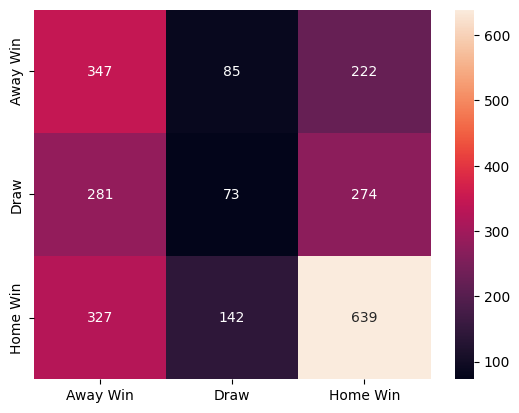

In [21]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Away Win', 'Draw', 'Home Win'],
            yticklabels=['Away Win', 'Draw', 'Home Win'])


In [22]:
# Vérification de la correspondance des classes encodées
for i, class_name in enumerate(le_result.classes_):
    print(f"Classe {i} : {class_name}")

Classe 0 : Away Win
Classe 1 : Draw
Classe 2 : Home Win


## Second model : random forest

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import scipy.stats as stats
features = ['home_encoded', 'away_encoded',
            'home_goals_avg', 'away_goals_avg',
            'home_conceded_avg', 'away_conceded_avg']

X = df[features]
y = df['result_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
class_counts = y_train.value_counts()
count_class_0 = class_counts.get(0, 1)
count_class_1 = class_counts.get(1, 1)
count_class_2 = class_counts.get(2, 1)
total_samples = len(y_train)

In [25]:
# calculation of weight_0 and weight_1 weight_2
# Class imbalance in training data
weight_0 = count_class_0 / (count_class_0 + count_class_1 + count_class_2)
weight_1 = count_class_1 / (count_class_0 + count_class_1 + count_class_2)
weight_2 = count_class_2 / (count_class_0 + count_class_1 + count_class_2)
print ('Weight of Home_win Class in Training: ',weight_0)
print ('Weight of Away_win Class in Training: ', weight_1)
print ('Weight of Draw Class in Training: ', weight_2)

Weight of Home_win Class in Training:  0.2835321196903118
Weight of Away_win Class in Training:  0.25768989328311365
Weight of Draw Class in Training:  0.4587779870265746


In [26]:
## Définition de l'espace de recherche
#Define the hyperparameters to tune for BayesSearchCV
search_space_rf = {
    'max_depth': stats.randint(2, 8),
    'n_estimators': stats.randint(100, 501),
    'min_samples_split': stats.randint(2, 26),
    'min_samples_leaf': stats.randint(2, 11),
    'bootstrap': [True, False],
    'class_weight': ['balanced']
}


In [27]:
rf_model = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=search_space_rf,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

In [28]:
print("\nRecherche des meilleurs hyperparamètres en cours avec RandomizedSearchCV...")
rf_model.fit(X_train, y_train)

print("Meilleurs paramètres trouvés :", rf_model.best_params_)
print(f"Meilleure exactitude en validation croisée : {rf_model.best_score_:.4f}")


Recherche des meilleurs hyperparamètres en cours avec RandomizedSearchCV...
Meilleurs paramètres trouvés : {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 108}
Meilleure exactitude en validation croisée : 0.4396


In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Évaluation finale sur l'ensemble de test avec le meilleur modèle trouvé
best_rf = rf_model.best_estimator_
predictions_rf = best_rf.predict(X_test)

print("=== Rapport de Classification (Random Forest optimisé) ===")
print(classification_report(y_test, predictions_rf, target_names=le_result.classes_))

=== Rapport de Classification (Random Forest optimisé) ===
              precision    recall  f1-score   support

    Away Win       0.40      0.50      0.45       678
        Draw       0.28      0.27      0.27       616
    Home Win       0.59      0.50      0.54      1096

    accuracy                           0.44      2390
   macro avg       0.42      0.42      0.42      2390
weighted avg       0.45      0.44      0.44      2390



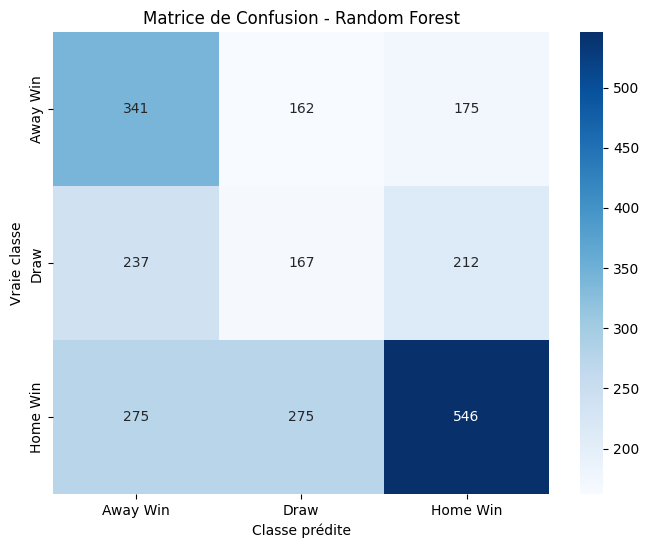

In [30]:
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, predictions_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_result.classes_,
            yticklabels=le_result.classes_)
plt.title('Matrice de Confusion - Random Forest')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.show()

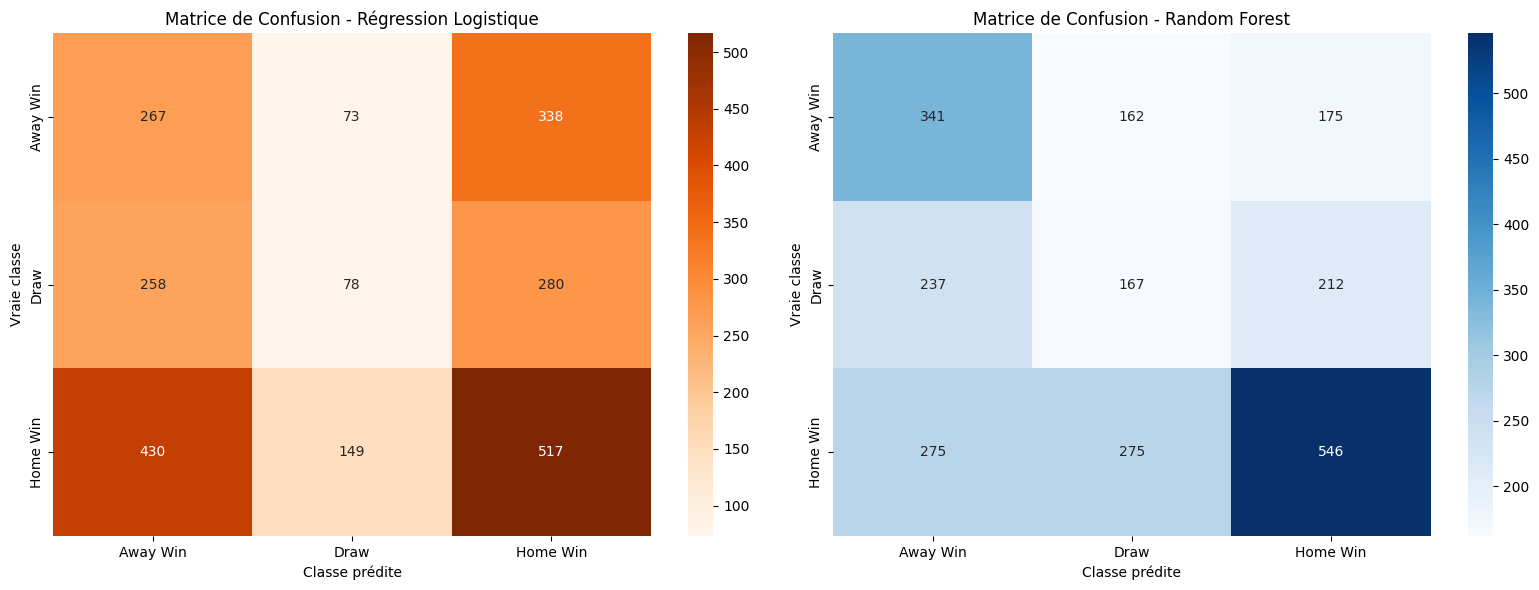

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcul des matrices de confusion
cm_lr = confusion_matrix(y_test, y_pred)
cm_rf = confusion_matrix(y_test, predictions_rf)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matrice pour la Régression Logistique
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=le_result.classes_,
            yticklabels=le_result.classes_)
axes[0].set_title('Matrice de Confusion - Régression Logistique')
axes[0].set_ylabel('Vraie classe')
axes[0].set_xlabel('Classe prédite')

# Matrice pour le Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=le_result.classes_,
            yticklabels=le_result.classes_)
axes[1].set_title('Matrice de Confusion - Random Forest')
axes[1].set_ylabel('Vraie classe')
axes[1].set_xlabel('Classe prédite')

plt.tight_layout()
plt.show()

In [32]:
# Vérification de la correspondance des classes encodées
for i, class_name in enumerate(le_result.classes_):
    print(f"Classe {i} : {class_name}")

Classe 0 : Away Win
Classe 1 : Draw
Classe 2 : Home Win
